In [ ]:
# DATA PREPROCESSING PIPELINE
# Cyber Attack Type Prediction


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# 1. LOAD DATASET

df = pd.read_csv("/content/drive/MyDrive/Cse427/Project /cybersecurity_attacks.csv")

print("Dataset shape:", df.shape)
print(df.head())


# 2. TARGET COLUMN

TARGET_COLUMN = "Attack Type"


# 3. SEPARATE FEATURES & TARGET

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]


# 4. ENCODE TARGET LABEL

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Attack Type Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)


# 5. IDENTIFY COLUMN TYPES

categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("\nCategorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))


# 6. PREPROCESSING PIPELINES


# Numerical pipeline
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", LabelEncoder())
])




# 7. HANDLE CATEGORICAL DATA

X_processed = X.copy()

for col in categorical_cols:
    X_processed[col] = X_processed[col].fillna(X_processed[col].mode()[0])
    X_processed[col] = LabelEncoder().fit_transform(X_processed[col])


# 8. SCALE NUMERICAL FEATURES

scaler = StandardScaler()
X_processed[numerical_cols] = scaler.fit_transform(X_processed[numerical_cols])


# 9. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Dataset shape: (40000, 25)
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... A

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# ============ ENCODING CATEGORICAL FEATURES ============
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# ============ SPLIT FEATURES & TARGET ============
X = df_encoded.drop("Attack Type", axis=1)
y = df_encoded["Attack Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 1. LOGISTIC REGRESSION
# =====================================================
print("===== Logistic Regression =====")

log_reg = LogisticRegression(
    max_iter=1000,
    solver="saga",
    n_jobs=-1
)

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


# =====================================================
# 2. RANDOM FOREST
# =====================================================
print("\n===== Random Forest =====")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# =====================================================
# 3. HISTOGRAM GRADIENT BOOSTING
# =====================================================
print("\n===== Histogram Gradient Boosting =====")

hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    random_state=42
)

hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_hgb))
print(classification_report(y_test, y_pred_hgb))




===== Logistic Regression =====


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 0.330125
              precision    recall  f1-score   support

           0       0.33      0.41      0.37      2686
           1       0.34      0.24      0.28      2653
           2       0.32      0.34      0.33      2661

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000


===== Random Forest =====
Accuracy: 0.323
              precision    recall  f1-score   support

           0       0.33      0.35      0.34      2686
           1       0.33      0.31      0.32      2653
           2       0.31      0.30      0.31      2661

    accuracy                           0.32      8000
   macro avg       0.32      0.32      0.32      8000
weighted avg       0.32      0.32      0.32      8000


===== Histogram Gradient Boosting =====
Accuracy: 0.3305
              precision    recall  f1-score   support

           0       0.33      0.34      0.34      2686
         

===== Logistic Regression =====


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 0.33025
              precision    recall  f1-score   support

           0       0.33      0.41      0.37      2686
           1       0.34      0.24      0.28      2653
           2       0.32      0.34      0.33      2661

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



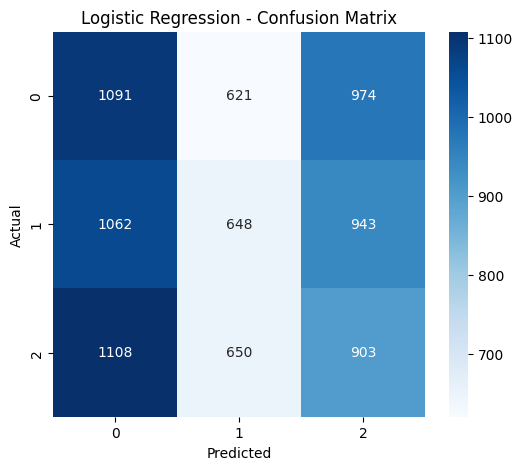

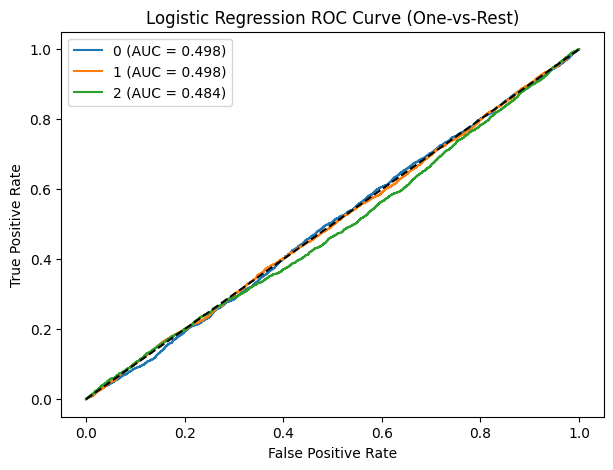


===== Random Forest =====
Accuracy: 0.323
              precision    recall  f1-score   support

           0       0.33      0.35      0.34      2686
           1       0.33      0.31      0.32      2653
           2       0.31      0.30      0.31      2661

    accuracy                           0.32      8000
   macro avg       0.32      0.32      0.32      8000
weighted avg       0.32      0.32      0.32      8000



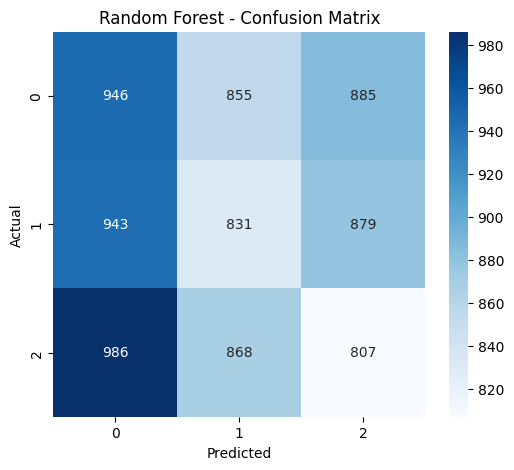

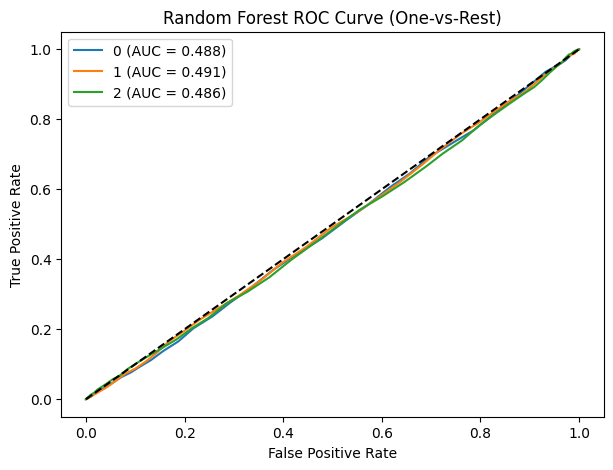


===== Histogram Gradient Boosting =====
Accuracy: 0.3305
              precision    recall  f1-score   support

           0       0.33      0.34      0.34      2686
           1       0.32      0.30      0.31      2653
           2       0.34      0.35      0.34      2661

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



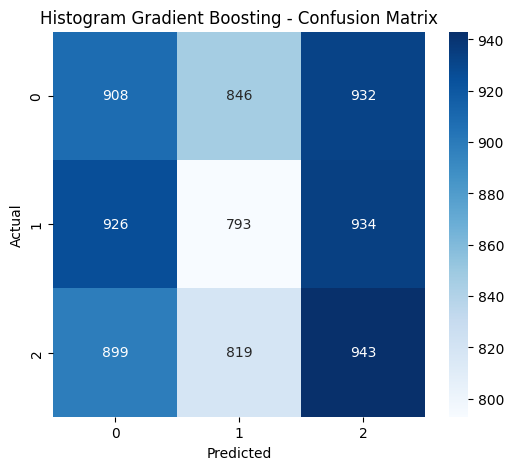

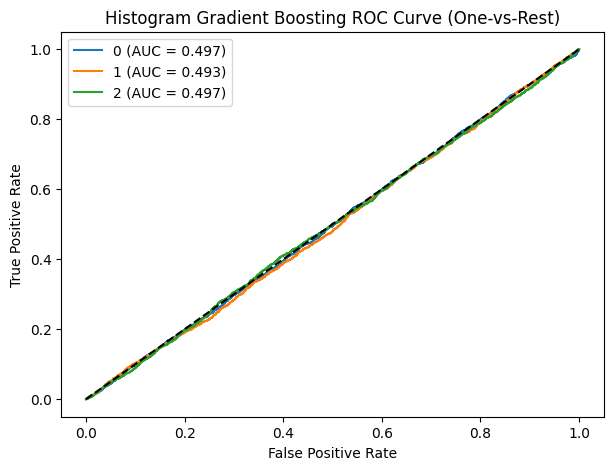

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import seaborn as sns
import numpy as np

# ================================
# ENCODE CATEGORICAL FEATURES
# ================================
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# ================================
# TRAIN–TEST SPLIT
# ================================
X = df_encoded.drop("Attack Type", axis=1)
y = df_encoded["Attack Type"]

classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Helper: Plot Confusion Matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Helper: ROC Curve for multi-class
def plot_roc(model, X_test, y_test, model_name):
    y_test_bin = label_binarize(y_test, classes=classes)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    plt.figure(figsize=(7, 5))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{model_name} ROC Curve (One-vs-Rest)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# =====================================================
# 1. LOGISTIC REGRESSION
# =====================================================
print("===== Logistic Regression =====")

log_reg = LogisticRegression(max_iter=1000, solver="saga", n_jobs=-1)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression - Confusion Matrix")
plot_roc(log_reg, X_test, y_test, "Logistic Regression")


# =====================================================
# 2. RANDOM FOREST
# =====================================================
print("\n===== Random Forest =====")

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

plot_conf_matrix(y_test, y_pred_rf, "Random Forest - Confusion Matrix")
plot_roc(rf, X_test, y_test, "Random Forest")


# =====================================================
# 3. HISTOGRAM GRADIENT BOOSTING
# =====================================================
print("\n===== Histogram Gradient Boosting =====")

hgb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, random_state=42)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_hgb))
print(classification_report(y_test, y_pred_hgb))

plot_conf_matrix(y_test, y_pred_hgb, "Histogram Gradient Boosting - Confusion Matrix")
plot_roc(hgb, X_test, y_test, "Histogram Gradient Boosting")



